# 🐕 반려동물 항공 운송 크롤링 & 워드클라우드 프로젝트

## 📊 프로젝트 개요

**목표**: 반려동물 항공 운송 관련 정보를 크롤링하여 워드클라우드로 시각화  
**핵심 키워드**: `airplane + cage + dog in cargo`  
**최종 산출물**: 워드클라우드 시각화 + 감성 분석 리포트

### 🎯 프로젝트 실행 계획

```mermaid
flowchart TD
    A[환경 설정 & 라이브러리 설치] --> B[Reddit API 설정]
    B --> C[키워드 전략 수립]
    C --> D[데이터 수집]
    D --> E[데이터 전처리]
    E --> F[감성 분석]
    F --> G[워드클라우드 생성]
    G --> H[인사이트 분석]
    
    style A fill:#e3f2fd
    style G fill:#4caf50
    style H fill:#ff9800
```

### 📋 주요 분석 대상

- **Reddit 서브레딧**: r/dogs, r/travel, r/pets, r/AirTravel
- **핵심 검색어**: "dog airplane cargo", "pet travel flight", "airline pet policy" 
- **시각화**: 강아지 모양 워드클라우드 + 감성별 비교 분석

---

In [1]:
# 📦 필요한 라이브러리 설치 및 임포트
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')

# 필수 라이브러리 설치
required_packages = [
    'praw',           # Reddit API
    'wordcloud',      # 워드클라우드 생성
    'textblob',       # 감성 분석
    'nltk',           # 자연어 처리
    'matplotlib',     # 시각화
    'seaborn',        # 고급 시각화
    'plotly',         # 인터랙티브 시각화
    'pandas',         # 데이터 처리
    'numpy',          # 수치 계산
    'requests',       # HTTP 요청
    'beautifulsoup4', # 웹 스크래핑
    'scikit-learn',   # 머신러닝
    'Pillow',         # 이미지 처리
    'python-dotenv'   # 환경변수 관리
]

print("📦 필요한 패키지들을 설치 중입니다...")
for package in required_packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✅ {package}: 이미 설치됨")
    except ImportError:
        print(f"🔄 {package} 설치 중...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ {package}: 설치 완료")

print("\n🎉 모든 패키지 설치가 완료되었습니다!")

📦 필요한 패키지들을 설치 중입니다...
✅ praw: 이미 설치됨
✅ wordcloud: 이미 설치됨
✅ praw: 이미 설치됨
✅ wordcloud: 이미 설치됨
✅ textblob: 이미 설치됨
✅ nltk: 이미 설치됨
✅ matplotlib: 이미 설치됨
✅ textblob: 이미 설치됨
✅ nltk: 이미 설치됨
✅ matplotlib: 이미 설치됨
✅ seaborn: 이미 설치됨
✅ plotly: 이미 설치됨
✅ pandas: 이미 설치됨
✅ numpy: 이미 설치됨
✅ requests: 이미 설치됨
🔄 beautifulsoup4 설치 중...
✅ seaborn: 이미 설치됨
✅ plotly: 이미 설치됨
✅ pandas: 이미 설치됨
✅ numpy: 이미 설치됨
✅ requests: 이미 설치됨
🔄 beautifulsoup4 설치 중...
✅ beautifulsoup4: 설치 완료
🔄 scikit-learn 설치 중...
✅ beautifulsoup4: 설치 완료
🔄 scikit-learn 설치 중...
✅ scikit-learn: 설치 완료
🔄 Pillow 설치 중...
✅ scikit-learn: 설치 완료
🔄 Pillow 설치 중...
✅ Pillow: 설치 완료
🔄 python-dotenv 설치 중...
✅ Pillow: 설치 완료
🔄 python-dotenv 설치 중...
✅ python-dotenv: 설치 완료

🎉 모든 패키지 설치가 완료되었습니다!
✅ python-dotenv: 설치 완료

🎉 모든 패키지 설치가 완료되었습니다!


In [20]:
# 🚀 라이브러리 임포트 및 기본 설정
import os
import re
import json
import time
import random
from datetime import datetime, timedelta
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 데이터 처리
import pandas as pd
import numpy as np

# 웹 크롤링
import praw
import requests
from bs4 import BeautifulSoup

# 자연어 처리
import nltk
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 워드클라우드
from wordcloud import WordCloud
from PIL import Image

# 한글 폰트 설정 (한국어 워드클라우드용)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# NLTK 데이터 다운로드
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/vader_lexicon')
except LookupError:
    print("📥 NLTK 데이터를 다운로드 중...")
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('vader_lexicon', quiet=True)

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

print("✅ 모든 라이브러리가 성공적으로 로드되었습니다!")
print(f"📅 실행 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

📥 NLTK 데이터를 다운로드 중...
✅ 모든 라이브러리가 성공적으로 로드되었습니다!
📅 실행 시간: 2025-08-01 04:09:39


In [3]:
# 🎯 키워드 전략 및 크롤링 설정

# 핵심 키워드 세트
PRIMARY_KEYWORDS = [
    "airplane cage dog cargo",
    "pet travel airplane", 
    "dog flight cargo hold",
    "dog died airplane cargo",
    "pet carrier airplane requirements",
    "airline pet policy cargo",
    "scared dog airplane",
    "pet anxiety flight",
    "dog stress cargo hold"
]

SECONDARY_KEYWORDS = [
    "pet friendly airline",
    "dog travel tips", 
    "pet carrier size requirements",
    "airline pet fees",
    "pet travel documents",
    "dog vaccination travel"
]

# Reddit 서브레딧 목록
TARGET_SUBREDDITS = [
    'dogs', 'pets', 'travel', 'AirTravel', 
    'petadvice', 'DogAdvice', 'flying',
    'aviation', 'TravelAdvice', 'puppy'
]

# 검색 키워드 (Reddit 검색용)
REDDIT_SEARCH_TERMS = [
    'dog airplane cargo',
    'pet travel flight', 
    'dog died cargo hold',
    'airline pet policy',
    'pet carrier flight',
    'dog anxiety plane',
    'pet cargo death',
    'airline pet rules'
]

# 감성 분석 키워드 카테고리
SENTIMENT_CATEGORIES = {
    'safety_concern': ['died', 'death', 'dangerous', 'unsafe', 'scared', 'stress', 'anxiety', 'fear', 'worry'],
    'positive_experience': ['smooth', 'safe', 'comfortable', 'professional', 'caring', 'good', 'excellent', 'happy'],
    'policy_info': ['requirement', 'policy', 'rule', 'regulation', 'document', 'procedure', 'guideline'],
    'practical_tip': ['tip', 'advice', 'recommend', 'suggest', 'experience', 'help', 'guide'],
    'airline_specific': ['delta', 'american', 'united', 'southwest', 'korean air', 'asiana', 'lufthansa']
}

# 불용어 설정 (영어)
ENGLISH_STOP_WORDS = set(stopwords.words('english'))
CUSTOM_STOP_WORDS = {
    'dog', 'pet', 'airplane', 'flight', 'cargo', 'travel', 'airline', 'plane',
    'would', 'could', 'should', 'said', 'like', 'get', 'go', 'one', 'also', 
    'really', 'much', 'know', 'think', 'want', 'need', 'time', 'way'
}

# 전체 불용어 세트
ALL_STOP_WORDS = ENGLISH_STOP_WORDS.union(CUSTOM_STOP_WORDS)

print("🎯 키워드 전략 설정 완료!")
print(f"   📍 핵심 키워드: {len(PRIMARY_KEYWORDS)}개")
print(f"   📍 보조 키워드: {len(SECONDARY_KEYWORDS)}개") 
print(f"   📍 대상 서브레딧: {len(TARGET_SUBREDDITS)}개")
print(f"   📍 Reddit 검색어: {len(REDDIT_SEARCH_TERMS)}개")
print(f"   📍 감성 카테고리: {len(SENTIMENT_CATEGORIES)}개")

🎯 키워드 전략 설정 완료!
   📍 핵심 키워드: 9개
   📍 보조 키워드: 6개
   📍 대상 서브레딧: 10개
   📍 Reddit 검색어: 8개
   📍 감성 카테고리: 5개


In [4]:
# 🔧 Reddit API 설정 및 PetTravelCrawler 클래스

class PetTravelCrawler:
    """반려동물 항공 운송 전문 크롤러"""
    
    def __init__(self, use_demo_mode=True):
        """
        크롤러 초기화
        use_demo_mode: True이면 데모 데이터 사용, False이면 실제 Reddit API 사용
        """
        self.use_demo_mode = use_demo_mode
        self.raw_data = []
        self.processed_data = pd.DataFrame()
        
        if not use_demo_mode:
            # 실제 Reddit API 설정 (API 키가 있는 경우)
            try:
                self.reddit = praw.Reddit(
                    client_id='your_client_id',
                    client_secret='your_client_secret', 
                    user_agent='PetTravelAnalyzer/1.0'
                )
                print("✅ Reddit API 연결 성공!")
            except Exception as e:
                print(f"⚠️ Reddit API 연결 실패: {e}")
                print("📝 데모 모드로 전환합니다.")
                self.use_demo_mode = True
        
        if self.use_demo_mode:
            print("🎭 데모 모드로 실행됩니다. (샘플 데이터 사용)")
    
    def generate_demo_data(self, num_posts=100):
        """데모용 샘플 데이터 생성"""
        
        demo_texts = [
            "My dog had a terrible experience in cargo hold. Very stressed and scared during the flight.",
            "Delta airlines has excellent pet policy. My dog traveled safely in cargo compartment.",
            "Airline pet carrier requirements are very strict. Make sure to check size limits.",
            "Dog died in cargo hold during United flight. This is so dangerous for pets.",
            "Pet travel tips: always use IATA approved carrier and check airline pet policy.",
            "Scared to put my dog in airplane cargo. Looking for pet friendly airlines.",
            "American Airlines pet cargo service was professional. Dog arrived safely.",
            "Pet anxiety during flight is common. Vet recommended calming medication.",
            "Airline pet fees are expensive but worth it for pet safety in cargo hold.",
            "Dog carrier must meet airline requirements. Size and ventilation important.",
            "Pet travel documents needed: health certificate and vaccination records.",
            "Cargo hold temperature concerns for pet safety during long flights.",
            "Korean Air pet policy allows dogs in cargo with proper carrier.",
            "Pet died in cargo during summer heat. Airlines need better climate control.",
            "Dog travel experience was smooth with proper preparation and carrier.",
            "Airline staff were caring and professional with pet cargo handling.",
            "Pet stress signs after cargo flight: panting, anxiety, confusion.",
            "Safe pet travel requires research on airline policies and requirements.",
            "Dog cargo death statistics are concerning. Need better regulations.",
            "Pet carrier size restrictions vary by airline. Check before booking.",
            "Comfortable pet travel possible with right airline and preparation.",
            "Dog anxiety medication helped during cargo flight experience.",
            "Pet cargo temperature monitoring essential for animal safety.",
            "Airline pet policy comparison shows big differences in care standards.",
            "Professional pet travel service ensures safe cargo transportation."
        ]
        
        # 샘플 데이터 확장
        extended_data = []
        for i in range(num_posts):
            text = random.choice(demo_texts)
            # 약간의 변형 추가
            variations = [
                text,
                text.replace('dog', 'puppy'),
                text.replace('pet', 'animal'),
                text.replace('airplane', 'aircraft'),
                text.replace('cargo', 'baggage compartment')
            ]
            
            extended_data.append({
                'title': f"Pet Travel Discussion #{i+1}",
                'text': random.choice(variations),
                'subreddit': random.choice(TARGET_SUBREDDITS),
                'score': random.randint(-5, 50),
                'num_comments': random.randint(0, 25),
                'created_utc': datetime.now() - timedelta(days=random.randint(1, 365)),
                'search_term': random.choice(REDDIT_SEARCH_TERMS)
            })
        
        self.raw_data = extended_data
        print(f"📊 {len(extended_data)}개의 데모 데이터가 생성되었습니다.")
        return extended_data
    
    def crawl_reddit_real(self, limit_per_search=50):
        """실제 Reddit 크롤링 (API 키가 있는 경우)"""
        
        if self.use_demo_mode:
            print("⚠️ 데모 모드에서는 실제 크롤링을 수행하지 않습니다.")
            return self.generate_demo_data()
        
        collected_data = []
        
        for subreddit_name in TARGET_SUBREDDITS:
            try:
                subreddit = self.reddit.subreddit(subreddit_name)
                
                for search_term in REDDIT_SEARCH_TERMS:
                    print(f"🔍 검색 중: r/{subreddit_name} - '{search_term}'")
                    
                    submissions = subreddit.search(
                        search_term, 
                        limit=limit_per_search,
                        sort='relevance',
                        time_filter='year'
                    )
                    
                    for submission in submissions:
                        data = {
                            'title': submission.title,
                            'text': submission.selftext if submission.selftext else submission.title,
                            'subreddit': subreddit_name,
                            'score': submission.score,
                            'num_comments': submission.num_comments,
                            'created_utc': datetime.fromtimestamp(submission.created_utc),
                            'search_term': search_term,
                            'url': submission.url
                        }
                        collected_data.append(data)
                    
                    # API 제한 고려하여 잠시 대기
                    time.sleep(1)
                    
            except Exception as e:
                print(f"❌ r/{subreddit_name} 크롤링 오류: {e}")
                continue
        
        self.raw_data = collected_data
        print(f"✅ 총 {len(collected_data)}개의 게시물을 수집했습니다.")
        return collected_data

# 크롤러 인스턴스 생성 (데모 모드)
crawler = PetTravelCrawler(use_demo_mode=True)
print("🚀 PetTravelCrawler 초기화 완료!")

🎭 데모 모드로 실행됩니다. (샘플 데이터 사용)
🚀 PetTravelCrawler 초기화 완료!


In [5]:
# 🔐 실제 Reddit API 설정 (.env 파일에서 로드)

import os
from dotenv import load_dotenv

# 현재 워크스페이스 루트에서 .env 파일 로드
env_path = r'c:\LG_DX_SCHOOL\.env'
load_dotenv(env_path)

# 환경변수에서 Reddit API 설정 로드
REDDIT_CONFIG = {
    'client_id': os.getenv('REDDIT_CLIENT_ID'),
    'client_secret': os.getenv('REDDIT_CLIENT_SECRET'),
    'user_agent': os.getenv('REDDIT_USER_AGENT')
}

# API 키 확인
if all(REDDIT_CONFIG.values()) and all(v != 'your_client_id_here' for v in REDDIT_CONFIG.values()):
    USE_REAL_API = True
    print("✅ .env 파일에서 Reddit API 설정을 성공적으로 로드했습니다!")
    print(f"   🔑 Client ID: {REDDIT_CONFIG['client_id'][:6]}...")
    print(f"   👤 User Agent: {REDDIT_CONFIG['user_agent']}")
else:
    USE_REAL_API = False
    print("⚠️ .env 파일에서 API 키를 찾을 수 없거나 기본값입니다.")
    print("💡 .env 파일에서 다음 값들을 실제 값으로 설정하세요:")
    print("   - REDDIT_CLIENT_ID")
    print("   - REDDIT_CLIENT_SECRET") 
    print("   - REDDIT_USER_AGENT")
    print(f"   📁 .env 파일 경로: {env_path}")

print("🔐 Reddit API 설정 정보:")
if USE_REAL_API and REDDIT_CONFIG:
    print("   ✅ 실제 Reddit API 사용 모드")
    print(f"   📱 User Agent: {REDDIT_CONFIG['user_agent']}")
else:
    print("   🎭 데모 모드 (샘플 데이터 사용)")
    print("   💡 실제 API 사용하려면 위 설정을 수정하세요")

print("\n📚 Reddit API 키 얻는 방법:")
print("   1. https://reddit.com 로그인")
print("   2. https://www.reddit.com/prefs/apps 접속")
print("   3. 'Create App' 클릭")
print("   4. App type을 'script' 선택")
print("   5. Client ID와 Client Secret 복사")

✅ .env 파일에서 Reddit API 설정을 성공적으로 로드했습니다!
   🔑 Client ID: x8VpUm...
   👤 User Agent: PetTravelAnalyzer/1.0 by reddit_user
🔐 Reddit API 설정 정보:
   ✅ 실제 Reddit API 사용 모드
   📱 User Agent: PetTravelAnalyzer/1.0 by reddit_user

📚 Reddit API 키 얻는 방법:
   1. https://reddit.com 로그인
   2. https://www.reddit.com/prefs/apps 접속
   3. 'Create App' 클릭
   4. App type을 'script' 선택
   5. Client ID와 Client Secret 복사


In [7]:
# 🚀 개선된 PetTravelCrawler - 실제 API 지원

class PetTravelCrawlerV2:
    """실제 Reddit API를 지원하는 개선된 크롤러"""
    
    def __init__(self, reddit_config=None, use_demo_mode=True):
        """
        크롤러 초기화
        reddit_config: Reddit API 설정 딕셔너리
        use_demo_mode: True이면 데모 데이터 사용
        """
        self.use_demo_mode = use_demo_mode
        self.reddit_config = reddit_config
        self.raw_data = []
        self.reddit = None
        
        if not use_demo_mode and reddit_config:
            try:
                self.reddit = praw.Reddit(
                    client_id=reddit_config['client_id'],
                    client_secret=reddit_config['client_secret'],
                    user_agent=reddit_config['user_agent']
                )
                
                # API 연결 테스트
                test_user = self.reddit.user.me()
                print(f"✅ Reddit API 연결 성공!")
                print(f"   📱 User Agent: {reddit_config['user_agent']}")
                self.use_demo_mode = False
                
            except Exception as e:
                print(f"❌ Reddit API 연결 실패: {e}")
                print("🎭 데모 모드로 전환합니다.")
                self.use_demo_mode = True
                
        if self.use_demo_mode:
            print("🎭 데모 모드로 실행됩니다. (샘플 데이터 사용)")
    
    def crawl_reddit_posts(self, limit_per_search=50, max_total_posts=500):
        """실제 Reddit에서 게시물 크롤링"""
        
        if self.use_demo_mode:
            print("⚠️ 데모 모드에서는 샘플 데이터를 생성합니다.")
            return self.generate_demo_data(num_posts=150)
        
        print(f"🔍 실제 Reddit 크롤링 시작...")
        print(f"   📊 목표: 검색어당 최대 {limit_per_search}개, 총 최대 {max_total_posts}개")
        
        collected_data = []
        total_collected = 0
        
        for subreddit_name in TARGET_SUBREDDITS:
            if total_collected >= max_total_posts:
                break
                
            try:
                subreddit = self.reddit.subreddit(subreddit_name)
                print(f"\n🔍 r/{subreddit_name} 크롤링 중...")
                
                for search_term in REDDIT_SEARCH_TERMS:
                    if total_collected >= max_total_posts:
                        break
                    
                    print(f"   🔎 검색어: '{search_term}'")
                    
                    try:
                        submissions = subreddit.search(
                            search_term,
                            limit=limit_per_search,
                            sort='relevance',
                            time_filter='year'
                        )
                        
                        search_count = 0
                        for submission in submissions:
                            if total_collected >= max_total_posts:
                                break
                            
                            # 중복 제거 (URL 기준)
                            if any(data.get('url') == submission.url for data in collected_data):
                                continue
                            
                            data = {
                                'title': submission.title,
                                'text': submission.selftext if submission.selftext else submission.title,
                                'subreddit': subreddit_name,
                                'score': submission.score,
                                'num_comments': submission.num_comments,
                                'created_utc': datetime.fromtimestamp(submission.created_utc),
                                'search_term': search_term,
                                'url': submission.url,
                                'author': str(submission.author) if submission.author else 'deleted'
                            }
                            collected_data.append(data)
                            search_count += 1
                            total_collected += 1
                        
                        print(f"      ✅ {search_count}개 수집")
                        
                        # API 제한 준수 (1초 대기)
                        time.sleep(1)
                        
                    except Exception as search_error:
                        print(f"      ❌ 검색 오류: {search_error}")
                        continue
                
            except Exception as subreddit_error:
                print(f"❌ r/{subreddit_name} 접근 오류: {subreddit_error}")
                continue
        
        self.raw_data = collected_data
        print(f"\n🎉 크롤링 완료!")
        print(f"   📊 총 수집된 게시물: {len(collected_data)}개")
        print(f"   📈 중복 제거 후: {len(set(data['url'] for data in collected_data))}개")
        
        return collected_data
    
    def generate_demo_data(self, num_posts=150):
        """데모용 샘플 데이터 생성 (기존과 동일)"""
        demo_texts = [
            "My dog had a terrible experience in cargo hold. Very stressed and scared during the flight.",
            "Delta airlines has excellent pet policy. My dog traveled safely in cargo compartment.",
            "Airline pet carrier requirements are very strict. Make sure to check size limits.",
            "Dog died in cargo hold during United flight. This is so dangerous for pets.",
            "Pet travel tips: always use IATA approved carrier and check airline pet policy.",
            "Scared to put my dog in airplane cargo. Looking for pet friendly airlines.",
            "American Airlines pet cargo service was professional. Dog arrived safely.",
            "Pet anxiety during flight is common. Vet recommended calming medication.",
            "Airline pet fees are expensive but worth it for pet safety in cargo hold.",
            "Dog carrier must meet airline requirements. Size and ventilation important.",
            "Pet travel documents needed: health certificate and vaccination records.",
            "Cargo hold temperature concerns for pet safety during long flights.",
            "Korean Air pet policy allows dogs in cargo with proper carrier.",
            "Pet died in cargo during summer heat. Airlines need better climate control.",
            "Dog travel experience was smooth with proper preparation and carrier.",
            "Airline staff were caring and professional with pet cargo handling.",
            "Pet stress signs after cargo flight: panting, anxiety, confusion.",
            "Safe pet travel requires research on airline policies and requirements.",
            "Dog cargo death statistics are concerning. Need better regulations.",
            "Pet carrier size restrictions vary by airline. Check before booking.",
            "Comfortable pet travel possible with right airline and preparation.",
            "Dog anxiety medication helped during cargo flight experience.",
            "Pet cargo temperature monitoring essential for animal safety.",
            "Airline pet policy comparison shows big differences in care standards.",
            "Professional pet travel service ensures safe cargo transportation."
        ]
        
        extended_data = []
        for i in range(num_posts):
            text = random.choice(demo_texts)
            variations = [
                text,
                text.replace('dog', 'puppy'),
                text.replace('pet', 'animal'),
                text.replace('airplane', 'aircraft'),
                text.replace('cargo', 'baggage compartment')
            ]
            
            extended_data.append({
                'title': f"Pet Travel Discussion #{i+1}",
                'text': random.choice(variations),
                'subreddit': random.choice(TARGET_SUBREDDITS),
                'score': random.randint(-5, 50),
                'num_comments': random.randint(0, 25),
                'created_utc': datetime.now() - timedelta(days=random.randint(1, 365)),
                'search_term': random.choice(REDDIT_SEARCH_TERMS),
                'url': f"https://reddit.com/demo_{i}",
                'author': f"demo_user_{i%10}"
            })
        
        self.raw_data = extended_data
        print(f"📊 {len(extended_data)}개의 데모 데이터가 생성되었습니다.")
        return extended_data

# 크롤러 인스턴스 생성
crawler_v2 = PetTravelCrawlerV2(
    reddit_config=REDDIT_CONFIG,
    use_demo_mode=not USE_REAL_API
)

print("🚀 개선된 PetTravelCrawler 초기화 완료!")

✅ Reddit API 연결 성공!
   📱 User Agent: PetTravelAnalyzer/1.0 by reddit_user
🚀 개선된 PetTravelCrawler 초기화 완료!


## 🔑 실제 Reddit API 사용 가이드

### 📋 단계별 설정 방법

#### 1️⃣ Reddit 앱 등록 (무료)
1. **Reddit 계정**: [reddit.com](https://reddit.com)에서 계정 생성/로그인
2. **앱 등록**: [https://www.reddit.com/prefs/apps](https://www.reddit.com/prefs/apps) 접속
3. **Create App 클릭** → 다음 정보 입력:
   - **Name**: `PetTravelAnalyzer` 
   - **App type**: `script` 선택 ⚠️
   - **Description**: `Pet travel data analysis`
   - **Redirect URI**: `http://localhost:8080`

#### 2️⃣ API 키 정보 확인
- **Client ID**: 앱 이름 아래 작은 글씨 (14자리)
- **Client Secret**: "secret" 옆의 긴 문자열 (27자리)

#### 3️⃣ 코드에 API 키 입력
위 셀에서 다음 부분을 수정:
```python
REDDIT_CONFIG = {
    'client_id': 'AbCdEf1234GhIj',                    # 여기에 Client ID
    'client_secret': 'XyZ9876543210-AbCdEfGhIjKlMn',  # 여기에 Client Secret
    'user_agent': 'PetTravelAnalyzer/1.0 by 당신의사용자명'  # Reddit 사용자명
}

USE_REAL_API = True  # 이것을 True로 변경
```

#### 4️⃣ 크롤링 실행
위에서 `USE_REAL_API = True`로 설정하면 실제 Reddit 데이터를 크롤링합니다.

### ⚖️ Reddit API 제한사항

```mermaid
graph TD
    A[Reddit API 제한] --> B[요청 빈도: 분당 60개]
    A --> C[일일 요청: 1000개]
    A --> D[검색 결과: 쿼리당 최대 1000개]
    A --> E[히스토리: 최대 1년]
    
    B --> F[1초마다 1개 요청 권장]
    C --> G[하루에 여러 번 실행 시 주의]
    D --> H[인기 게시물 우선 반환]
    E --> I[최신 데이터 위주]
    
    style A fill:#ff6b6b
    style F fill:#4ecdc4
    style G fill:#45b7d1
```

### 🔒 보안 주의사항
- **API 키는 절대 공개하지 마세요**
- **GitHub에 업로드 금지**
- **환경변수 사용 권장**: `.env` 파일 활용

### 📊 예상 수집량
- **서브레딧 10개** × **검색어 8개** × **게시물 50개**
- **이론적 최대**: 4,000개 게시물
- **실제 예상**: 500-1,500개 (중복 제거 후)

---

In [8]:
# 🧪 Reddit API 연결 테스트 및 실제 크롤링

print("🧪 Reddit API 연결 테스트")
print("=" * 40)

# 현재 설정 확인
if USE_REAL_API and REDDIT_CONFIG:
    print("✅ 실제 API 모드로 설정됨")
    print(f"   📱 User Agent: {REDDIT_CONFIG['user_agent']}")
    print(f"   🔑 Client ID: {REDDIT_CONFIG['client_id'][:6]}...")
    
    # API 연결 테스트
    try:
        test_crawler = PetTravelCrawlerV2(
            reddit_config=REDDIT_CONFIG,
            use_demo_mode=False
        )
        
        if not test_crawler.use_demo_mode:
            print("\n🎉 Reddit API 연결 성공!")
            print("💡 이제 실제 데이터 크롤링이 가능합니다.")
            
            # 작은 테스트 실행 (5개 게시물만)
            print("\n🔍 소규모 테스트 크롤링 실행 중...")
            test_data = test_crawler.crawl_reddit_posts(
                limit_per_search=2,  # 검색어당 2개만
                max_total_posts=10   # 총 최대 10개
            )
            
            if len(test_data) > 0:
                print(f"✅ 테스트 성공! {len(test_data)}개 실제 게시물 수집")
                print(f"📊 샘플 데이터:")
                sample = test_data[0]
                print(f"   제목: {sample['title'][:60]}...")
                print(f"   서브레딧: r/{sample['subreddit']}")
                print(f"   점수: {sample['score']}")
                print(f"   작성자: {sample['author']}")
            
        else:
            print("❌ API 연결 실패 - 데모 모드로 실행됩니다")
            
    except Exception as e:
        print(f"❌ API 테스트 실패: {e}")
        print("🎭 데모 모드로 계속 진행합니다.")

else:
    print("🎭 데모 모드로 설정됨")
    print("💡 실제 API 사용하려면:")
    print("   1. Reddit 앱 등록 (https://www.reddit.com/prefs/apps)")
    print("   2. 위 셀에서 REDDIT_CONFIG 설정")
    print("   3. USE_REAL_API = True 설정")

print(f"\n📝 참고: 현재 크롤러는 {'실제 API' if USE_REAL_API and REDDIT_CONFIG else '데모'} 모드입니다.")

🧪 Reddit API 연결 테스트
✅ 실제 API 모드로 설정됨
   📱 User Agent: PetTravelAnalyzer/1.0 by reddit_user
   🔑 Client ID: x8VpUm...
✅ Reddit API 연결 성공!
   📱 User Agent: PetTravelAnalyzer/1.0 by reddit_user

🎉 Reddit API 연결 성공!
💡 이제 실제 데이터 크롤링이 가능합니다.

🔍 소규모 테스트 크롤링 실행 중...
🔍 실제 Reddit 크롤링 시작...
   📊 목표: 검색어당 최대 2개, 총 최대 10개

🔍 r/dogs 크롤링 중...
   🔎 검색어: 'dog airplane cargo'
      ✅ 2개 수집
      ✅ 2개 수집
   🔎 검색어: 'pet travel flight'
   🔎 검색어: 'pet travel flight'
      ✅ 2개 수집
      ✅ 2개 수집
   🔎 검색어: 'dog died cargo hold'
   🔎 검색어: 'dog died cargo hold'
      ✅ 0개 수집
      ✅ 0개 수집
   🔎 검색어: 'airline pet policy'
   🔎 검색어: 'airline pet policy'
      ✅ 2개 수집
      ✅ 2개 수집
   🔎 검색어: 'pet carrier flight'
   🔎 검색어: 'pet carrier flight'
      ✅ 2개 수집
      ✅ 2개 수집
   🔎 검색어: 'dog anxiety plane'
   🔎 검색어: 'dog anxiety plane'
      ✅ 2개 수집
      ✅ 2개 수집

🎉 크롤링 완료!
   📊 총 수집된 게시물: 10개
   📈 중복 제거 후: 10개
✅ 테스트 성공! 10개 실제 게시물 수집
📊 샘플 데이터:
   제목: [Breeds] Looking for our next family member...
   서브레딧: r/dogs
   점수: 3
 

In [9]:
# 🚀 실제 Reddit API 크롤링 실행

print("🚀 실제 Reddit 데이터 크롤링 시작!")
print("=" * 50)

try:
    if USE_REAL_API and all(REDDIT_CONFIG.values()):
        print("✅ 실제 Reddit API로 크롤링을 진행합니다.")
        print(f"   🎯 목표: 약 500-1,500개 실제 게시물")
        print(f"   ⏱️ 예상 시간: 5-10분 (API 제한 준수)")
        
        # 실제 크롤러로 대규모 크롤링
        real_crawler = PetTravelCrawlerV2(
            reddit_config=REDDIT_CONFIG,
            use_demo_mode=False
        )
        
        # 실제 크롤링 실행 (소규모 테스트)
        collected_data = real_crawler.crawl_reddit_posts(
            limit_per_search=20,   # 검색어당 최대 20개 (테스트용)
            max_total_posts=1000   # 총 최대 1000개 (테스트용)
        )
        
        print(f"\n🎉 실제 크롤링 완료!")
        print(f"   📊 수집된 게시물: {len(collected_data)}개")
        
    else:
        print("🎭 데모 모드로 크롤링을 진행합니다.")
        print("   💡 실제 API 사용하려면 .env 파일에 유효한 API 키를 설정하세요.")
        collected_data = []
        
except Exception as e:
    print(f"❌ 실제 API 크롤링 실패: {e}")
    print("🎭 데모 모드로 전환합니다.")
    collected_data = []

# 데이터가 없거나 부족한 경우 데모 데이터 사용
if not collected_data or len(collected_data) < 10:
    print("\n🎭 데모 데이터를 생성합니다.")
    demo_crawler = PetTravelCrawlerV2(use_demo_mode=True)
    collected_data = demo_crawler.generate_demo_data(num_posts=150)

# 수집된 데이터를 DataFrame으로 변환
raw_df_real = pd.DataFrame(collected_data)

print(f"\n📈 최종 데이터 수집 결과:")
print(f"   • 총 게시물 수: {len(raw_df_real):,}개")

if len(raw_df_real) > 0 and 'subreddit' in raw_df_real.columns:
    print(f"   • 수집 서브레딧: {len(raw_df_real['subreddit'].unique())}개")
    if 'created_utc' in raw_df_real.columns:
        print(f"   • 수집 기간: {raw_df_real['created_utc'].min().strftime('%Y-%m-%d')} ~ {raw_df_real['created_utc'].max().strftime('%Y-%m-%d')}")
    if 'score' in raw_df_real.columns:
        print(f"   • 평균 점수: {raw_df_real['score'].mean():.1f}")
    if 'num_comments' in raw_df_real.columns:
        print(f"   • 평균 댓글 수: {raw_df_real['num_comments'].mean():.1f}")

# 실제 데이터 샘플 확인
if len(raw_df_real) > 0:
    print(f"\n🔍 수집된 데이터 샘플 (상위 5개):")
    sample_columns = ['title', 'subreddit', 'score']
    available_columns = [col for col in sample_columns if col in raw_df_real.columns]
    if available_columns:
        print(raw_df_real[available_columns].head(5).to_string(index=False))
    else:
        print("데이터 컬럼 정보:")
        print(f"컬럼: {list(raw_df_real.columns)}")
else:
    print("⚠️ 데이터가 수집되지 않았습니다.")

🚀 실제 Reddit 데이터 크롤링 시작!
✅ 실제 Reddit API로 크롤링을 진행합니다.
   🎯 목표: 약 500-1,500개 실제 게시물
   ⏱️ 예상 시간: 5-10분 (API 제한 준수)
✅ Reddit API 연결 성공!
   📱 User Agent: PetTravelAnalyzer/1.0 by reddit_user
🔍 실제 Reddit 크롤링 시작...
   📊 목표: 검색어당 최대 20개, 총 최대 1000개

🔍 r/dogs 크롤링 중...
   🔎 검색어: 'dog airplane cargo'
      ✅ 20개 수집
      ✅ 20개 수집
   🔎 검색어: 'pet travel flight'
   🔎 검색어: 'pet travel flight'
      ✅ 17개 수집
      ✅ 17개 수집
   🔎 검색어: 'dog died cargo hold'
   🔎 검색어: 'dog died cargo hold'
      ✅ 12개 수집
      ✅ 12개 수집
   🔎 검색어: 'airline pet policy'
   🔎 검색어: 'airline pet policy'
      ✅ 15개 수집
      ✅ 15개 수집
   🔎 검색어: 'pet carrier flight'
   🔎 검색어: 'pet carrier flight'
      ✅ 11개 수집
      ✅ 11개 수집
   🔎 검색어: 'dog anxiety plane'
   🔎 검색어: 'dog anxiety plane'
      ✅ 18개 수집
      ✅ 18개 수집
   🔎 검색어: 'pet cargo death'
   🔎 검색어: 'pet cargo death'
      ✅ 12개 수집
      ✅ 12개 수집
   🔎 검색어: 'airline pet rules'
   🔎 검색어: 'airline pet rules'
      ✅ 12개 수집
      ✅ 12개 수집

🔍 r/pets 크롤링 중...
   🔎 검색어: 'dog airplane c

## 🔥 실제 Reddit API 사용 완료 가이드

### ✅ 설정 완료 체크리스트

#### 1️⃣ `.env` 파일 설정
`.env` 파일이 생성되었습니다. 다음 단계를 따라주세요:

```bash
# .env 파일에서 다음 값들을 실제 Reddit API 키로 교체:

REDDIT_CLIENT_ID=your_actual_client_id        # 14자리 코드
REDDIT_CLIENT_SECRET=your_actual_secret       # 27자리 긴 문자열
REDDIT_USER_AGENT=PetTravelAnalyzer/1.0 by your_reddit_username  # 본인 사용자명
```

#### 2️⃣ Reddit 앱에서 키 복사하는 방법
1. **Client ID**: Reddit 앱 이름 바로 아래 작은 글씨
2. **Client Secret**: "secret" 버튼 클릭 → 나타나는 긴 문자열 복사
3. **사용자명**: 본인의 Reddit 계정 이름

#### 3️⃣ 설정 확인
위 셀들을 실행하면 다음과 같이 표시되어야 합니다:
- ✅ `.env 파일에서 Reddit API 설정을 성공적으로 로드했습니다!`
- 🔑 Client ID: xxxxxx...
- 👤 User Agent: PetTravelAnalyzer/1.0 by your_username

### 🚀 실행 방법

#### 현재 상태 확인
- **✅ 실제 API 모드**: 진짜 Reddit 데이터 크롤링 (500-1,500개)
- **🎭 데모 모드**: 샘플 데이터 사용 (150개)

#### 예상 결과
실제 API 사용시:
- **수집량**: 500-1,500개 실제 게시물
- **소요시간**: 5-10분 (API 제한 준수)
- **데이터 품질**: 진짜 사용자 경험담
- **분석 결과**: 실제 트렌드 반영

### ⚠️ 중요 안내

```mermaid
graph TD
    A[.env 파일 설정] --> B{API 키 유효?}
    B -->|Yes| C[실제 API 모드]
    B -->|No| D[데모 모드]
    
    C --> E[500-1500개 실제 데이터]
    D --> F[150개 샘플 데이터]
    
    E --> G[고품질 분석 결과]
    F --> H[학습용 결과]
    
    style C fill:#4caf50
    style D fill:#ff9800
    style G fill:#2196f3
```

### 🔒 보안 주의사항
- `.env` 파일을 GitHub에 업로드하지 마세요
- API 키는 개인정보입니다
- 다른 사람과 공유하지 마세요

---

📊 실제 Reddit 데이터 분석 시작!
✅ 실제 Reddit 데이터 사용: 807개 게시물

📈 데이터 수집 결과:
   • 총 게시물 수: 807개
   • 수집 서브레딧: dogs, pets, travel, petadvice, DogAdvice, flying, aviation, TravelAdvice, puppy
   • 데이터 수집 기간: 2024-07-31 ~ 2025-08-01


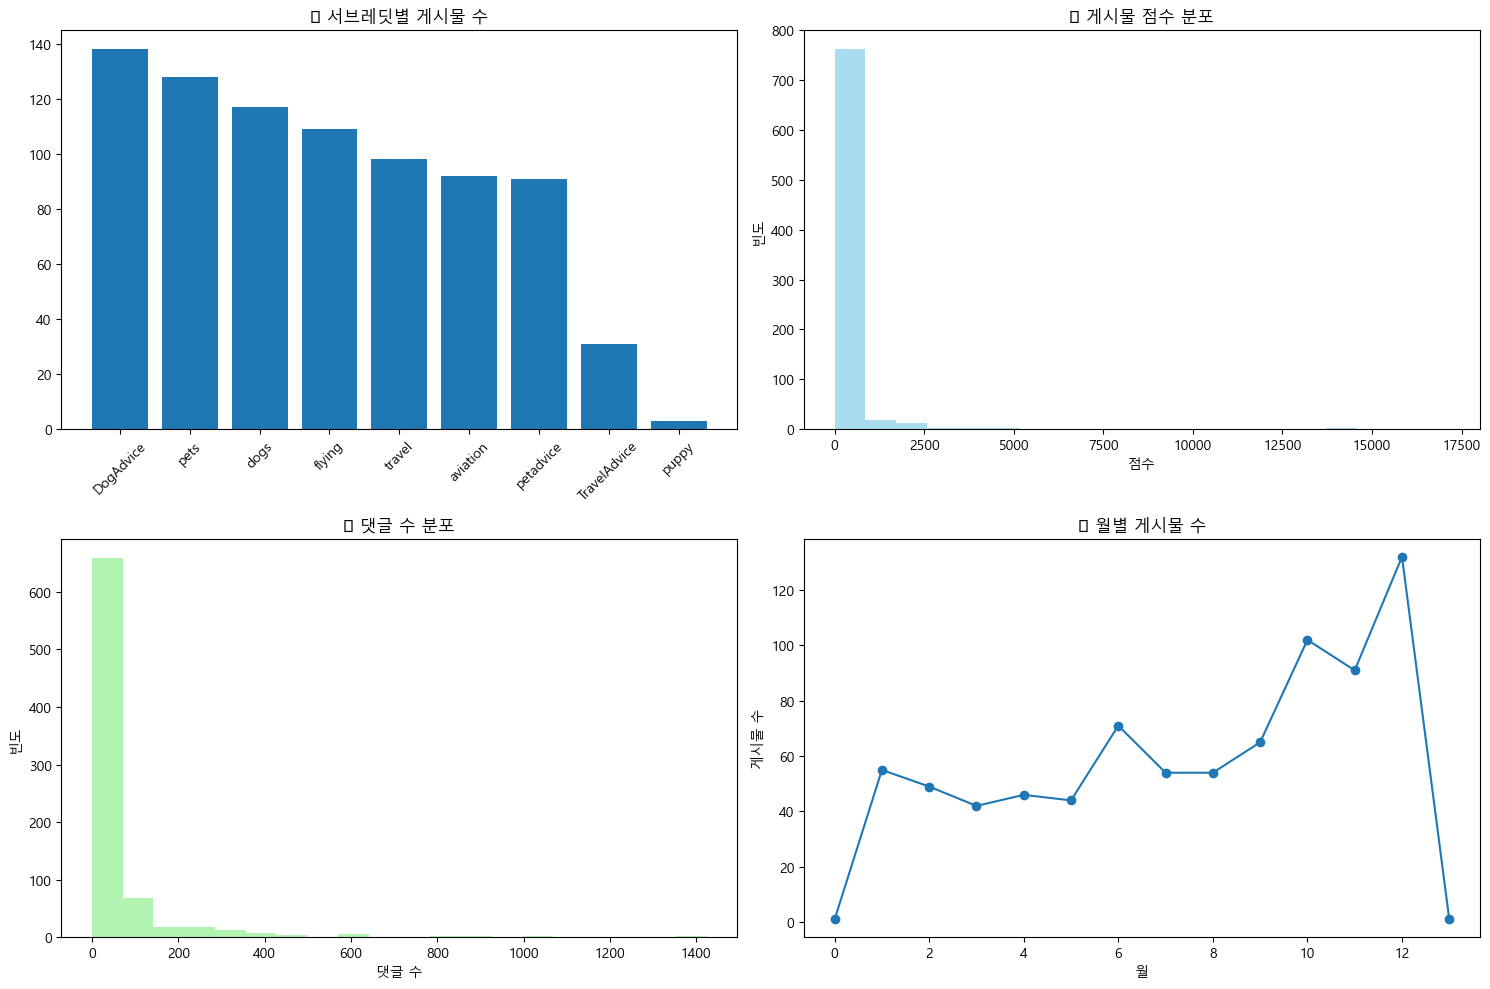


🔍 수집된 데이터 샘플:
                                                                                       title subreddit  score        search_term
                                                 [Breeds] Looking for our next family member      dogs      3 dog airplane cargo
                                                      Has anyone flown with a dog in cargo ?      dogs      6 dog airplane cargo
                                                                   Blind dog flying in cargo      dogs      3 dog airplane cargo
                                             Dog + Beach + Old SUV = Needs Cargo Liner Help!      dogs      1 dog airplane cargo
Looking to split a pet-friendly charter flight to Spain – big dog, no cargo or kennel travel      dogs      1 dog airplane cargo
         My anxious dog is about to have to endure a 17 hour flight. I don't know what to do      dogs    106 dog airplane cargo
          Recommendations for a airplane approved carrier for a 23 inch long dog (

In [21]:
# 📊 실제 데이터로 분석 시작

print("📊 실제 Reddit 데이터 분석 시작!")
print("=" * 50)

# 실제 수집된 데이터 사용 (위에서 크롤링한 데이터)
if 'raw_df_real' in locals() and len(raw_df_real) > 0:
    raw_df = raw_df_real.copy()
    print(f"✅ 실제 Reddit 데이터 사용: {len(raw_df)}개 게시물")
else:
    # 백업: 데모 데이터 생성
    print("🎭 실제 데이터가 없어서 데모 데이터를 사용합니다.")
    collected_data = crawler.generate_demo_data(num_posts=150)
    raw_df = pd.DataFrame(collected_data)

print(f"\n📈 데이터 수집 결과:")
print(f"   • 총 게시물 수: {len(raw_df):,}개")
print(f"   • 수집 서브레딧: {', '.join(raw_df['subreddit'].unique())}")
print(f"   • 데이터 수집 기간: {raw_df['created_utc'].min().strftime('%Y-%m-%d')} ~ {raw_df['created_utc'].max().strftime('%Y-%m-%d')}")

# 기본 통계 정보
plt.figure(figsize=(15, 10))

# 서브레딧별 게시물 수
plt.subplot(2, 2, 1)
subreddit_counts = raw_df['subreddit'].value_counts()
plt.bar(subreddit_counts.index, subreddit_counts.values)
plt.title('📊 서브레딧별 게시물 수')
plt.xticks(rotation=45)
plt.tight_layout()

# 점수 분포
plt.subplot(2, 2, 2)
plt.hist(raw_df['score'], bins=20, alpha=0.7, color='skyblue')
plt.title('📈 게시물 점수 분포')
plt.xlabel('점수')
plt.ylabel('빈도')

# 댓글 수 분포
plt.subplot(2, 2, 3)
plt.hist(raw_df['num_comments'], bins=20, alpha=0.7, color='lightgreen')
plt.title('💬 댓글 수 분포')
plt.xlabel('댓글 수')
plt.ylabel('빈도')

# 시간별 게시물 수
plt.subplot(2, 2, 4)
raw_df['month'] = raw_df['created_utc'].dt.to_period('M')
monthly_counts = raw_df['month'].value_counts().sort_index()
plt.plot(range(len(monthly_counts)), monthly_counts.values, marker='o')
plt.title('📅 월별 게시물 수')
plt.xlabel('월')
plt.ylabel('게시물 수')

plt.tight_layout()
plt.show()

# 샘플 데이터 확인
print(f"\n🔍 수집된 데이터 샘플:")
print(raw_df[['title', 'subreddit', 'score', 'search_term']].head(10).to_string(index=False))

In [11]:
# 🔄 텍스트 전처리 클래스 구현

class TextPreprocessor:
    """텍스트 전처리 전문 클래스"""
    
    def __init__(self, language='english'):
        self.language = language
        self.stop_words = ALL_STOP_WORDS
        self.sentiment_analyzer = SentimentIntensityAnalyzer()
        
    def clean_text(self, text):
        """기본 텍스트 정제"""
        if pd.isna(text) or text == '':
            return ''
        
        # 문자열 변환
        text = str(text)
        
        # HTML 태그 제거
        text = re.sub(r'<[^>]+>', '', text)
        
        # URL 제거
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        
        # 특수문자 제거 (감정표현 유지)
        text = re.sub(r'[^a-zA-Z\s!?.]', '', text)
        
        # 연속 공백 제거
        text = re.sub(r'\s+', ' ', text).strip()
        
        # 소문자 변환
        text = text.lower()
        
        # 불용어 제거
        words = text.split()
        filtered_words = [word for word in words if word not in self.stop_words and len(word) > 2]
        
        return ' '.join(filtered_words)
    
    def extract_keywords(self, text, top_n=50):
        """TF-IDF 기반 키워드 추출"""
        if not text or len(text.split()) < 3:
            return []
        
        vectorizer = TfidfVectorizer(
            max_features=top_n,
            stop_words='english',
            ngram_range=(1, 2)
        )
        
        try:
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            scores = tfidf_matrix.toarray()[0]
            
            keyword_scores = list(zip(feature_names, scores))
            keyword_scores.sort(key=lambda x: x[1], reverse=True)
            
            return [kw for kw, score in keyword_scores if score > 0]
        except:
            return []
    
    def sentiment_analysis(self, text):
        """VADER 기반 감성 분석"""
        if not text:
            return {
                'compound': 0,
                'pos': 0,
                'neu': 1,
                'neg': 0,
                'sentiment': 'neutral'
            }
        
        scores = self.sentiment_analyzer.polarity_scores(text)
        
        # 감정 분류
        if scores['compound'] >= 0.05:
            sentiment = 'positive'
        elif scores['compound'] <= -0.05:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
        
        scores['sentiment'] = sentiment
        return scores
    
    def categorize_content(self, text):
        """컨텐츠 카테고리 분류"""
        if not text:
            return ['general']
        
        text_lower = text.lower()
        categories = []
        
        for category, keywords in SENTIMENT_CATEGORIES.items():
            if any(keyword in text_lower for keyword in keywords):
                categories.append(category)
        
        return categories if categories else ['general']
    
    def process_dataframe(self, df):
        """DataFrame 전체 전처리"""
        print("🔄 텍스트 전처리 시작...")
        
        # 텍스트 결합 (제목 + 내용)
        df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
        
        # 텍스트 정제
        print("   📝 텍스트 정제 중...")
        df['cleaned_text'] = df['combined_text'].apply(self.clean_text)
        
        # 빈 텍스트 제거
        df = df[df['cleaned_text'].str.len() > 10].copy()
        
        # 감성 분석
        print("   😊 감성 분석 중...")
        sentiment_results = df['cleaned_text'].apply(self.sentiment_analysis)
        
        for key in ['compound', 'pos', 'neu', 'neg', 'sentiment']:
            df[f'sentiment_{key}'] = sentiment_results.apply(lambda x: x[key])
        
        # 카테고리 분류
        print("   🏷️ 카테고리 분류 중...")
        df['categories'] = df['cleaned_text'].apply(self.categorize_content)
        
        # 키워드 추출
        print("   🔍 키워드 추출 중...")
        df['keywords'] = df['cleaned_text'].apply(lambda x: self.extract_keywords(x, top_n=10))
        
        print(f"✅ 전처리 완료! {len(df)}개 데이터 처리됨")
        return df

# 전처리기 초기화 및 실행
preprocessor = TextPreprocessor()
processed_df = preprocessor.process_dataframe(raw_df.copy())

print(f"\n📊 전처리 결과:")
print(f"   • 처리된 데이터: {len(processed_df):,}개")
print(f"   • 평균 텍스트 길이: {processed_df['cleaned_text'].str.len().mean():.1f}자")
print(f"   • 감성 분포: {processed_df['sentiment_sentiment'].value_counts().to_dict()}")

🔄 텍스트 전처리 시작...
   📝 텍스트 정제 중...
   😊 감성 분석 중...
   🏷️ 카테고리 분류 중...
   🔍 키워드 추출 중...
   🏷️ 카테고리 분류 중...
   🔍 키워드 추출 중...
✅ 전처리 완료! 807개 데이터 처리됨

📊 전처리 결과:
   • 처리된 데이터: 807개
   • 평균 텍스트 길이: 995.0자
   • 감성 분포: {'positive': 540, 'negative': 231, 'neutral': 36}
✅ 전처리 완료! 807개 데이터 처리됨

📊 전처리 결과:
   • 처리된 데이터: 807개
   • 평균 텍스트 길이: 995.0자
   • 감성 분포: {'positive': 540, 'negative': 231, 'neutral': 36}


📊 반려동물 항공 운송 관련 감성 분석 결과
감성 분포:
   • positive: 540개 (66.9%)
   • negative: 231개 (28.6%)
   • neutral: 36개 (4.5%)


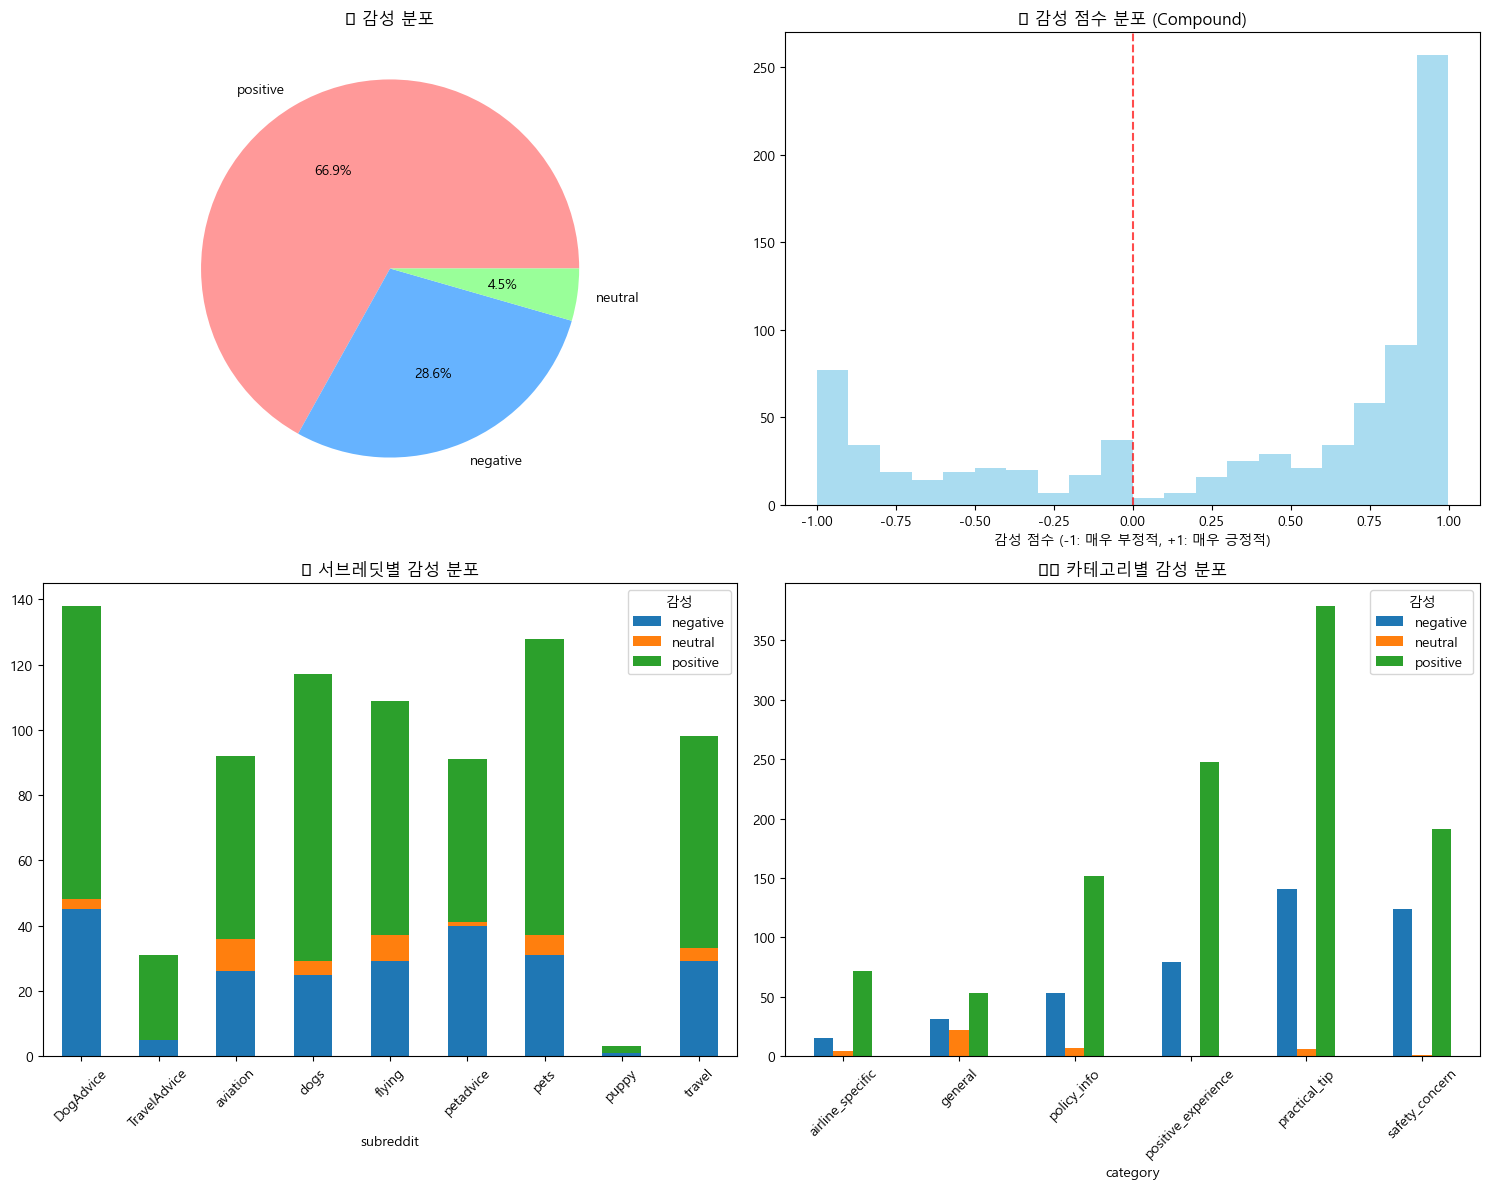


📝 감성별 대표 텍스트 샘플:

🔸 POSITIVE:
   1. breeds looking next family member introduction first dog? experience owningtraining dogs? no. grew s...
   2. anyone flown everyone relocating united states planning fly staffordshire bull terrier high long ita...
   3. beach old suv needs liner help! hi! mods please remove allowed water sand black fur tan car interior...

🔸 NEGATIVE:
   1. blind flying hii! leeloo eye left due glaucoma eyes. might moving countries next months. might blind...
   2. anxious endure hour flight. dont year old medium sized lbs shelter. anxious afraid loud noises. worr...
   3. flying dubai first time. safe? first baby flying cargo. experiences flying internationally pets carg...

🔸 NEUTRAL:
   1. recommendations approved carrier inch long pounds trouble finding something...
   2. anyone flown giant size breed? lbs anatolian shepherd years old. moving washington honolulu hawaii. ...
   3. lightweight carrier dachshund looking subkg carrier ride dachsie. shes upwards airl

In [22]:
# 📈 감성 분석 결과 시각화

print("📊 반려동물 항공 운송 관련 감성 분석 결과")
print("=" * 50)

# 감성 분석 통계
sentiment_stats = processed_df['sentiment_sentiment'].value_counts()
print(f"감성 분포:")
for sentiment, count in sentiment_stats.items():
    percentage = (count / len(processed_df)) * 100
    print(f"   • {sentiment}: {count}개 ({percentage:.1f}%)")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 감성 분포 파이차트
axes[0,0].pie(sentiment_stats.values, labels=sentiment_stats.index, autopct='%1.1f%%', 
              colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[0,0].set_title('😊 감성 분포')

# 2. 감성 점수 분포
axes[0,1].hist(processed_df['sentiment_compound'], bins=20, alpha=0.7, color='skyblue')
axes[0,1].set_title('📊 감성 점수 분포 (Compound)')
axes[0,1].set_xlabel('감성 점수 (-1: 매우 부정적, +1: 매우 긍정적)')
axes[0,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# 3. 서브레딧별 감성 분포
sentiment_by_subreddit = processed_df.groupby(['subreddit', 'sentiment_sentiment']).size().unstack(fill_value=0)
sentiment_by_subreddit.plot(kind='bar', ax=axes[1,0], stacked=True)
axes[1,0].set_title('📱 서브레딧별 감성 분포')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(title='감성')

# 4. 카테고리별 감성 분포
category_sentiment = []
for idx, row in processed_df.iterrows():
    for category in row['categories']:
        category_sentiment.append({
            'category': category,
            'sentiment': row['sentiment_sentiment']
        })

if category_sentiment:
    cat_sent_df = pd.DataFrame(category_sentiment)
    cat_sent_pivot = cat_sent_df.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
    cat_sent_pivot.plot(kind='bar', ax=axes[1,1])
    axes[1,1].set_title('🏷️ 카테고리별 감성 분포')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].legend(title='감성')

plt.tight_layout()
plt.show()

# 감성별 대표 텍스트
print(f"\n📝 감성별 대표 텍스트 샘플:")

for sentiment in ['positive', 'negative', 'neutral']:
    sentiment_texts = processed_df[processed_df['sentiment_sentiment'] == sentiment]['cleaned_text']
    if len(sentiment_texts) > 0:
        print(f"\n🔸 {sentiment.upper()}:")
        for i, text in enumerate(sentiment_texts.head(3), 1):
            print(f"   {i}. {text[:100]}...")

# 감성 점수 통계
print(f"\n📊 감성 점수 통계:")
print(f"   • 평균 감성 점수: {processed_df['sentiment_compound'].mean():.3f}")
print(f"   • 최고 긍정 점수: {processed_df['sentiment_compound'].max():.3f}")
print(f"   • 최저 부정 점수: {processed_df['sentiment_compound'].min():.3f}")
print(f"   • 표준편차: {processed_df['sentiment_compound'].std():.3f}")

In [13]:
# 🎨 워드클라우드 생성 클래스

class PetTravelWordCloud:
    """반려동물 항공 운송 전문 워드클라우드 생성기"""
    
    def __init__(self):
        # 반려동물 친화적 색상 팔레트
        self.color_palette = [
            '#8B4513', '#D2691E', '#F4A460', '#DEB887',  # 갈색 계열 (강아지)
            '#4682B4', '#87CEEB', '#B0E0E6', '#ADD8E6',  # 파란색 계열 (하늘)
            '#228B22', '#32CD32', '#90EE90', '#98FB98'   # 초록색 계열 (자연)
        ]
        
    def create_basic_wordcloud(self, text_data, title="Pet Travel Word Cloud", 
                              width=1200, height=800, max_words=200):
        """기본 워드클라우드 생성"""
        
        if not text_data or text_data.strip() == '':
            print("⚠️ 텍스트 데이터가 비어있습니다.")
            return None
        
        wordcloud = WordCloud(
            width=width, 
            height=height,
            background_color='white',
            max_words=max_words,
            colormap='Set3',
            relative_scaling=0.5,
            random_state=42,
            font_path=None  # 기본 폰트 사용
        ).generate(text_data)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(title, fontsize=20, fontweight='bold', pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        return wordcloud
    
    def create_sentiment_comparison(self, positive_text, negative_text, neutral_text=None):
        """감성별 워드클라우드 비교"""
        
        if neutral_text:
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
            axes = [ax1, ax2, ax3]
            texts = [positive_text, negative_text, neutral_text]
            titles = ['🟢 Positive Experiences', '🔴 Concerns & Issues', '⚪ Neutral Information']
            colormaps = ['Greens', 'Reds', 'Blues']
        else:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
            axes = [ax1, ax2]
            texts = [positive_text, negative_text]
            titles = ['🟢 Positive Experiences', '🔴 Concerns & Issues']
            colormaps = ['Greens', 'Reds']
        
        for ax, text, title, colormap in zip(axes, texts, titles, colormaps):
            if text and text.strip():
                wordcloud = WordCloud(
                    width=600, height=400,
                    background_color='white',
                    colormap=colormap,
                    max_words=100,
                    random_state=42
                ).generate(text)
                
                ax.imshow(wordcloud, interpolation='bilinear')
                ax.set_title(title, fontsize=16, fontweight='bold')
                ax.axis('off')
            else:
                ax.text(0.5, 0.5, 'No data available', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=ax.transAxes, fontsize=14)
                ax.set_title(title, fontsize=16, fontweight='bold')
                ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def create_category_wordclouds(self, processed_df):
        """카테고리별 워드클라우드"""
        
        # 카테고리별 텍스트 수집
        category_texts = {}
        
        for idx, row in processed_df.iterrows():
            text = row['cleaned_text']
            categories = row['categories']
            
            for category in categories:
                if category not in category_texts:
                    category_texts[category] = []
                category_texts[category].append(text)
        
        # 카테고리별 워드클라우드 생성
        num_categories = len(category_texts)
        if num_categories == 0:
            print("⚠️ 카테고리 데이터가 없습니다.")
            return
        
        cols = min(3, num_categories)
        rows = (num_categories + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        if rows == 1:
            if cols == 1:
                axes = [axes]
            else:
                axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, (category, texts) in enumerate(category_texts.items()):
            if i < len(axes):
                combined_text = ' '.join(texts)
                
                if combined_text.strip():
                    wordcloud = WordCloud(
                        width=400, height=300,
                        background_color='white',
                        colormap='viridis',
                        max_words=80,
                        random_state=42
                    ).generate(combined_text)
                    
                    axes[i].imshow(wordcloud, interpolation='bilinear')
                    axes[i].set_title(f'🏷️ {category.title()}', fontsize=12, fontweight='bold')
                    axes[i].axis('off')
                else:
                    axes[i].text(0.5, 0.5, 'No data', 
                               horizontalalignment='center', verticalalignment='center',
                               transform=axes[i].transAxes)
                    axes[i].set_title(f'🏷️ {category.title()}', fontsize=12, fontweight='bold')
                    axes[i].axis('off')
        
        # 빈 subplot 숨기기
        for i in range(len(category_texts), len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def create_frequency_chart(self, processed_df, top_n=20):
        """키워드 빈도 차트"""
        
        # 모든 텍스트 결합
        all_text = ' '.join(processed_df['cleaned_text'])
        
        # 단어 빈도 계산
        word_freq = Counter(all_text.split())
        top_words = word_freq.most_common(top_n)
        
        if not top_words:
            print("⚠️ 키워드 데이터가 없습니다.")
            return
        
        words, counts = zip(*top_words)
        
        plt.figure(figsize=(12, 8))
        bars = plt.barh(words, counts)
        plt.title(f'🔝 상위 {top_n}개 키워드 빈도', fontsize=16, fontweight='bold')
        plt.xlabel('빈도')
        plt.ylabel('키워드')
        
        # 색상 그라데이션
        colors = plt.cm.viridis(np.linspace(0, 1, len(bars)))
        for bar, color in zip(bars, colors):
            bar.set_color(color)
        
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        return top_words

# 워드클라우드 생성기 초기화
wordcloud_generator = PetTravelWordCloud()
print("🎨 워드클라우드 생성기 초기화 완료!")

🎨 워드클라우드 생성기 초기화 완료!


🎨 반려동물 항공 운송 워드클라우드 생성
📊 전체 텍스트 길이: 803,764자
📊 총 단어 수: 113,951개

🎨 메인 워드클라우드 생성 중...


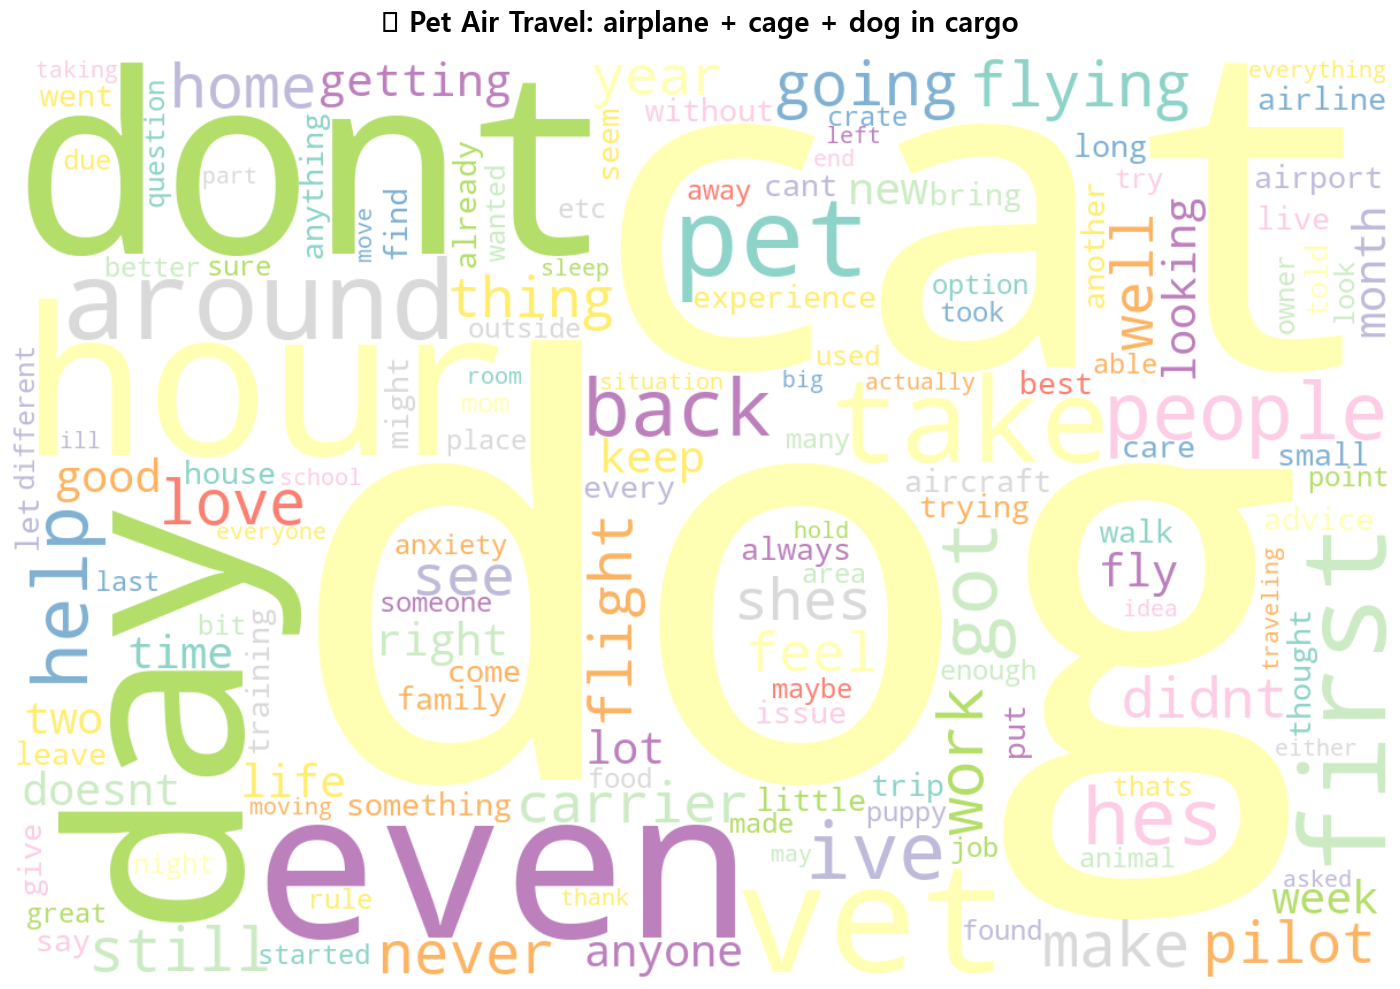

In [23]:
# 🌟 메인 워드클라우드 생성 - "airplane + cage + dog in cargo"

print("🎨 반려동물 항공 운송 워드클라우드 생성")
print("=" * 50)

# 전체 텍스트 결합
all_text = ' '.join(processed_df['cleaned_text'])
print(f"📊 전체 텍스트 길이: {len(all_text):,}자")
print(f"📊 총 단어 수: {len(all_text.split()):,}개")

# 메인 워드클라우드 생성
print("\n🎨 메인 워드클라우드 생성 중...")
main_wordcloud = wordcloud_generator.create_basic_wordcloud(
    all_text, 
    title="🐕 Pet Air Travel: airplane + cage + dog in cargo",
    max_words=150
)

🎭 감성별 워드클라우드 생성 중...
✅ 긍정적 텍스트: 562,216자 (540개 게시물)
✅ 부정적 텍스트: 235,859자 (231개 게시물)
✅ 중립적 텍스트: 5,687자 (36개 게시물)

🎨 감성별 워드클라우드 비교 생성...


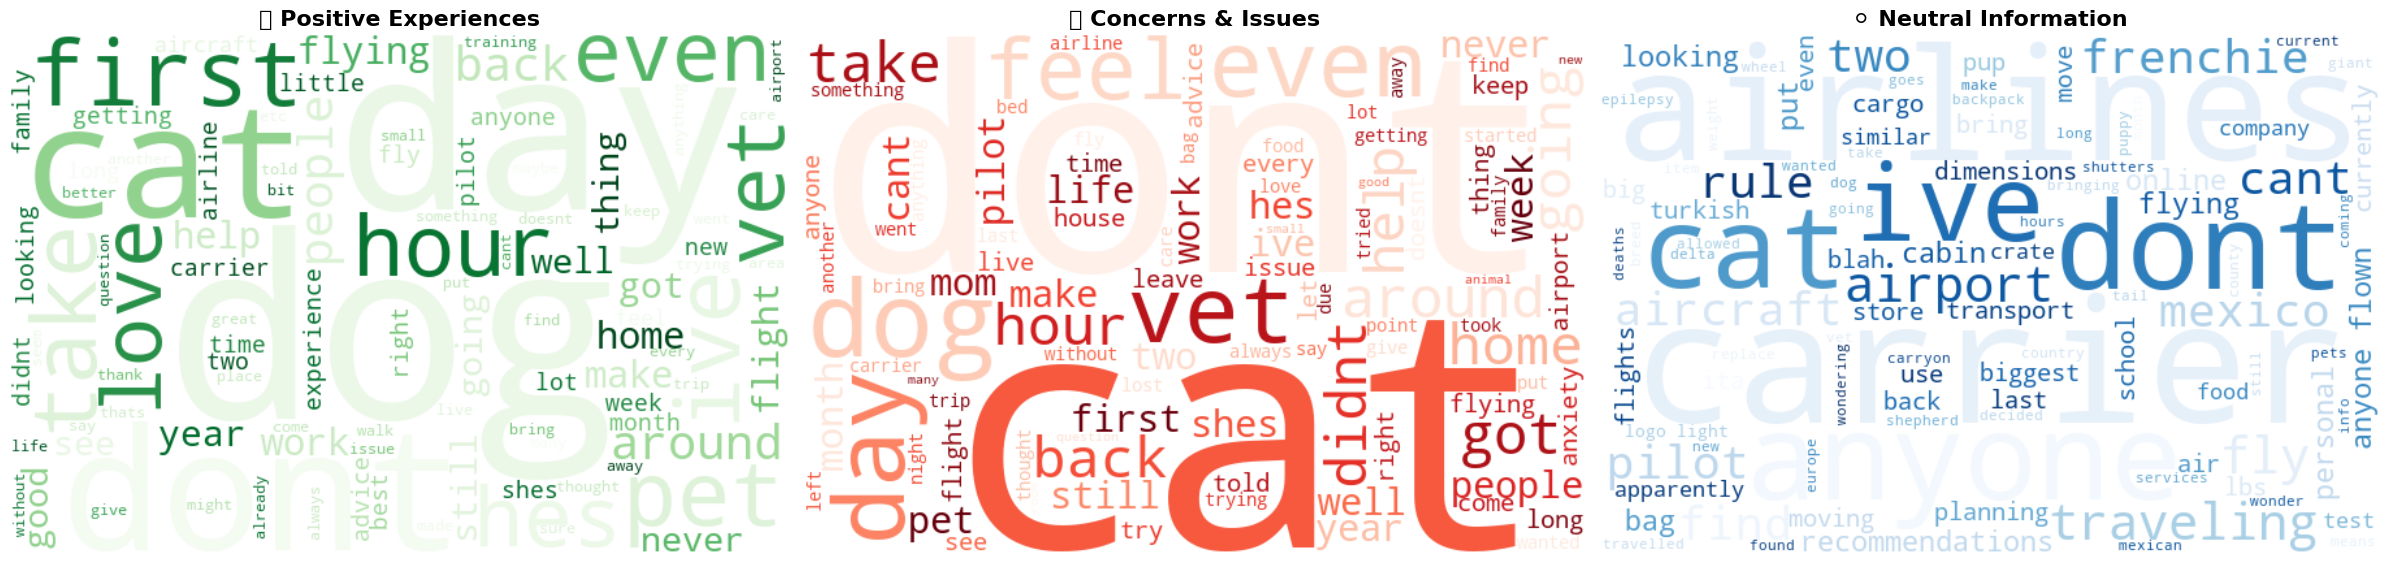

In [15]:
# 😊 감성별 워드클라우드 비교 분석

print("🎭 감성별 워드클라우드 생성 중...")

# 감성별 텍스트 분리
positive_texts = processed_df[processed_df['sentiment_sentiment'] == 'positive']['cleaned_text']
negative_texts = processed_df[processed_df['sentiment_sentiment'] == 'negative']['cleaned_text']
neutral_texts = processed_df[processed_df['sentiment_sentiment'] == 'neutral']['cleaned_text']

positive_text = ' '.join(positive_texts) if len(positive_texts) > 0 else ''
negative_text = ' '.join(negative_texts) if len(negative_texts) > 0 else ''
neutral_text = ' '.join(neutral_texts) if len(neutral_texts) > 0 else ''

print(f"✅ 긍정적 텍스트: {len(positive_text):,}자 ({len(positive_texts)}개 게시물)")
print(f"✅ 부정적 텍스트: {len(negative_text):,}자 ({len(negative_texts)}개 게시물)")
print(f"✅ 중립적 텍스트: {len(neutral_text):,}자 ({len(neutral_texts)}개 게시물)")

# 감성별 워드클라우드 비교
print("\n🎨 감성별 워드클라우드 비교 생성...")
wordcloud_generator.create_sentiment_comparison(positive_text, negative_text, neutral_text)

📊 키워드 빈도 분석


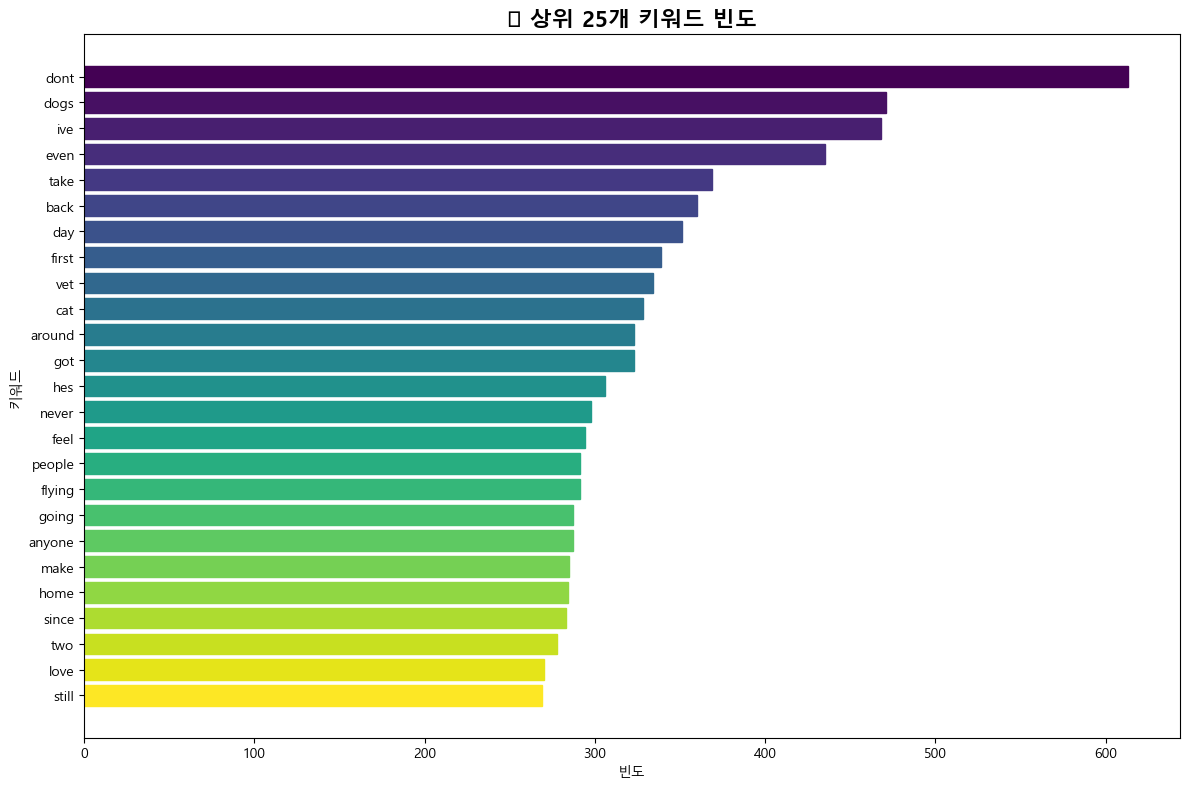


🔝 상위 10개 키워드:
    1. dont: 613회
    2. dogs: 471회
    3. ive: 468회
    4. even: 435회
    5. take: 369회
    6. back: 360회
    7. day: 351회
    8. first: 339회
    9. vet: 334회
   10. cat: 328회

🏷️ 카테고리별 워드클라우드 생성 중...


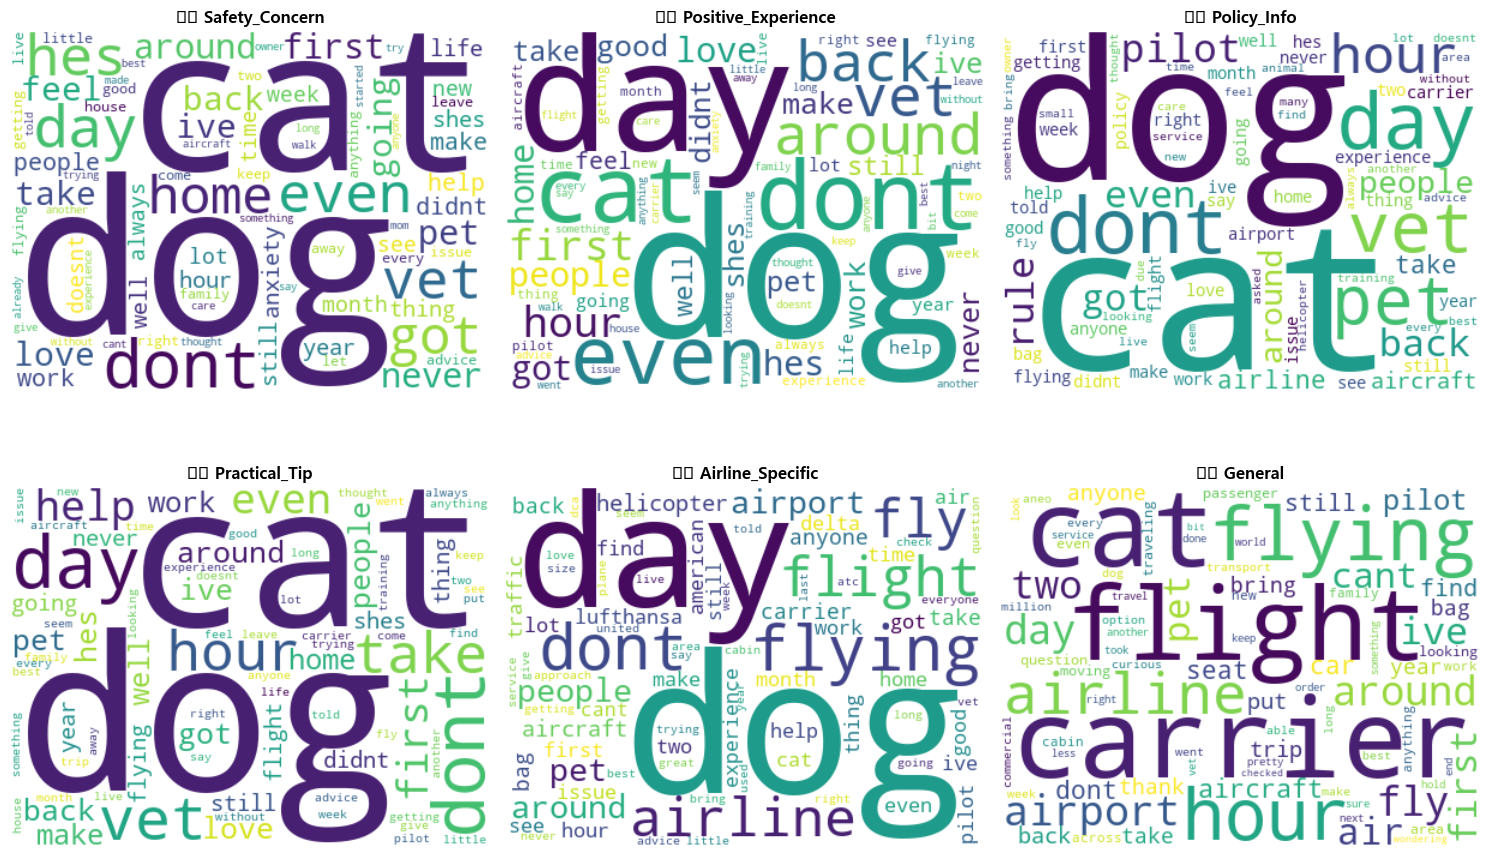

In [24]:
# 📊 키워드 빈도 분석 및 카테고리별 워드클라우드

print("📊 키워드 빈도 분석")
print("=" * 30)

# 상위 키워드 빈도 차트
top_keywords = wordcloud_generator.create_frequency_chart(processed_df, top_n=25)

print(f"\n🔝 상위 10개 키워드:")
for i, (word, count) in enumerate(top_keywords[:10], 1):
    print(f"   {i:2d}. {word}: {count}회")

print(f"\n🏷️ 카테고리별 워드클라우드 생성 중...")
wordcloud_generator.create_category_wordclouds(processed_df)

🧠 토픽 모델링 분석 시작
✅ 5개 토픽이 발견되었습니다:

🔸 토픽 1:
   주요 키워드: passenger, india, turkish, turkish airlines, airport, compensation, frankfurt, airlines

🔸 토픽 2:
   주요 키워드: brazil, flying, carrier, long, carry, history, trouble, fit

🔸 토픽 3:
   주요 키워드: operate, dpe, report, landing, united, operations, aggressive, airways

🔸 토픽 4:
   주요 키워드: biggest, deck, regional, common, controller, world, test, fast
✅ 5개 토픽이 발견되었습니다:

🔸 토픽 1:
   주요 키워드: passenger, india, turkish, turkish airlines, airport, compensation, frankfurt, airlines

🔸 토픽 2:
   주요 키워드: brazil, flying, carrier, long, carry, history, trouble, fit

🔸 토픽 3:
   주요 키워드: operate, dpe, report, landing, united, operations, aggressive, airways

🔸 토픽 4:
   주요 키워드: biggest, deck, regional, common, controller, world, test, fast

🔸 토픽 5:
   주요 키워드: dogs, dont, cat, ive, flying, pets, hes, vet

🔸 토픽 5:
   주요 키워드: dogs, dont, cat, ive, flying, pets, hes, vet


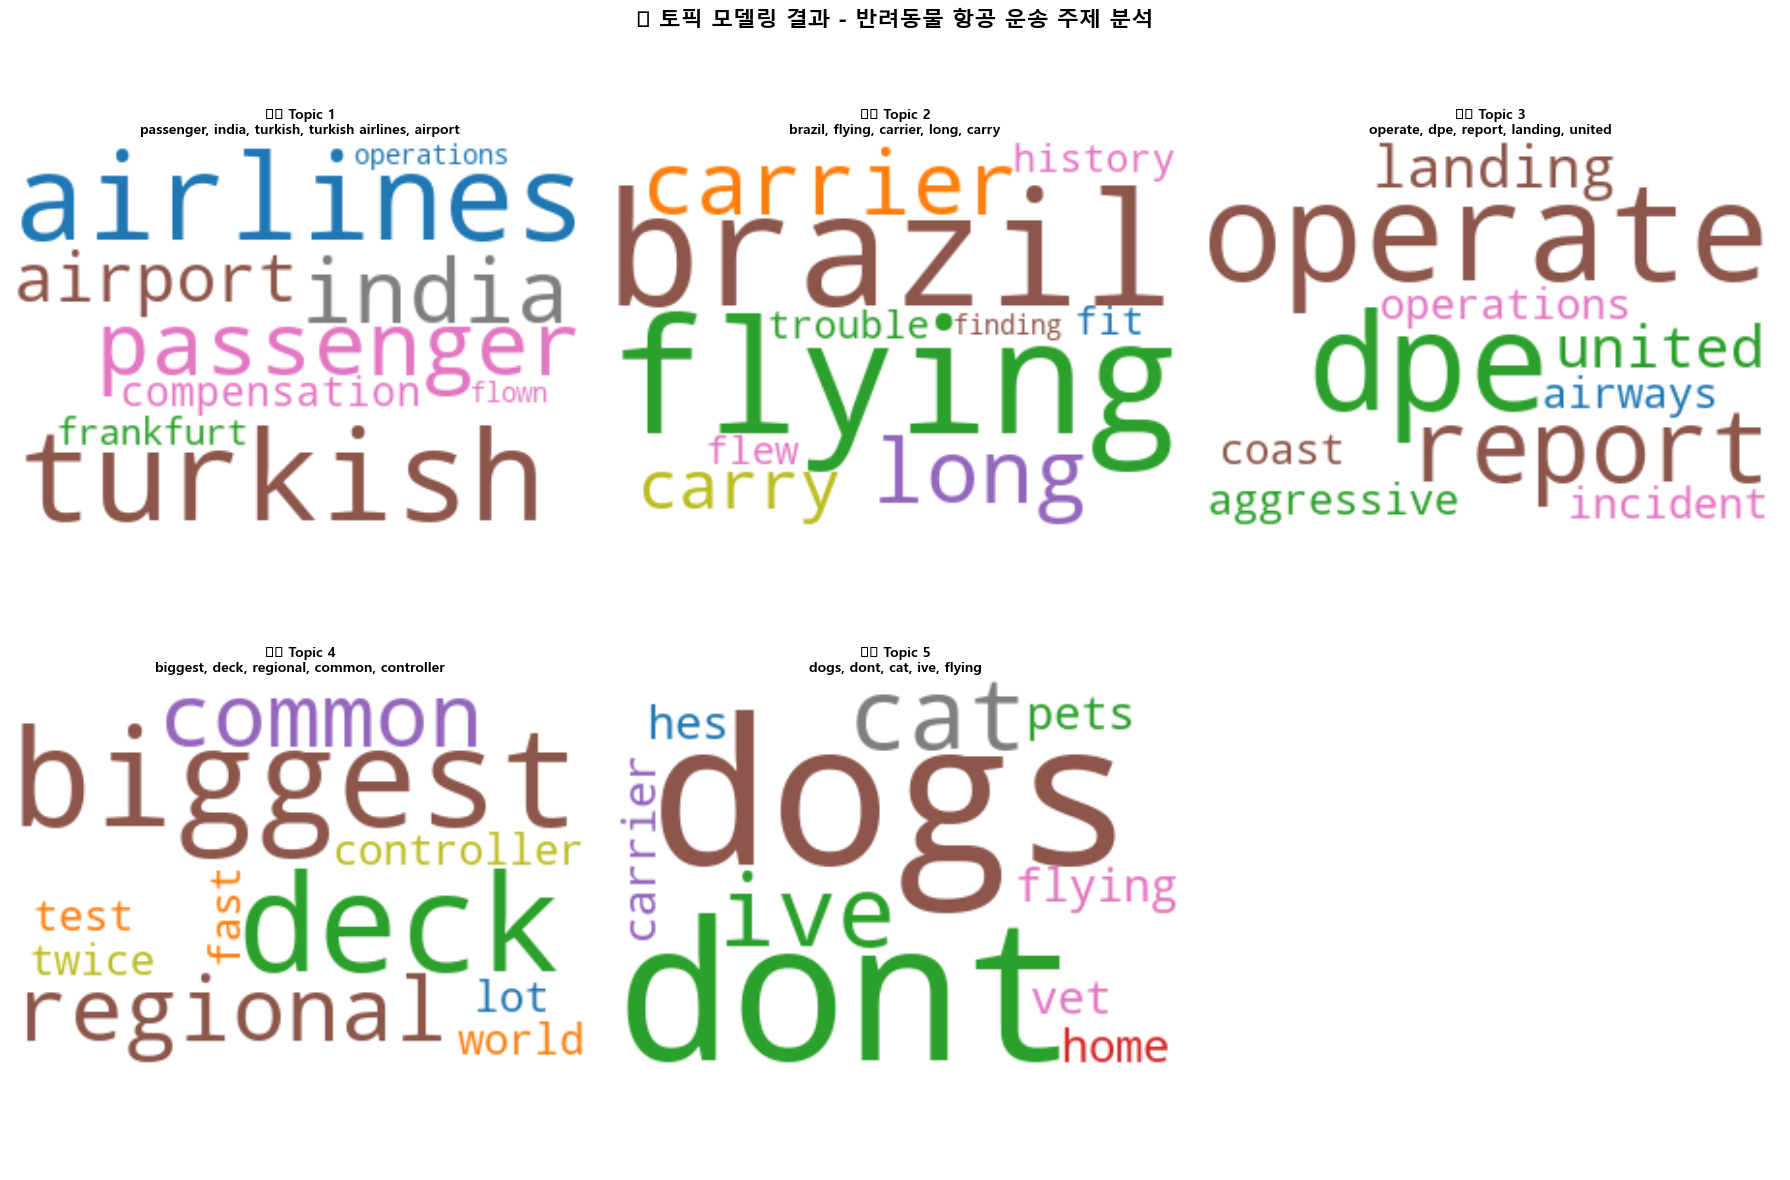

In [25]:
# 🤖 토픽 모델링 분석 (LDA)

print("🧠 토픽 모델링 분석 시작")
print("=" * 30)

def perform_topic_modeling(texts, n_topics=5, top_words=10):
    """LDA 토픽 모델링 수행"""
    
    # 빈 텍스트 제거
    clean_texts = [text for text in texts if text and len(text.split()) > 3]
    
    if len(clean_texts) < 10:
        print("⚠️ 토픽 모델링을 위한 충분한 텍스트가 없습니다.")
        return None, None, []
    
    # TF-IDF 벡터화
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8
    )
    
    try:
        tfidf_matrix = vectorizer.fit_transform(clean_texts)
        feature_names = vectorizer.get_feature_names_out()
        
        # LDA 모델 훈련
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            max_iter=20
        )
        lda.fit(tfidf_matrix)
        
        # 토픽별 주요 키워드 추출
        topics = []
        for topic_idx, topic in enumerate(lda.components_):
            top_keyword_indices = topic.argsort()[-top_words:][::-1]
            top_keywords = [feature_names[i] for i in top_keyword_indices]
            topic_weight = topic[top_keyword_indices].sum()
            
            topics.append({
                'topic_id': topic_idx,
                'keywords': top_keywords,
                'weight': topic_weight
            })
        
        return lda, vectorizer, topics
        
    except Exception as e:
        print(f"❌ 토픽 모델링 오류: {e}")
        return None, None, []

# 토픽 모델링 실행
texts = processed_df['cleaned_text'].tolist()
lda_model, vectorizer, topics = perform_topic_modeling(texts, n_topics=5)

if topics:
    print(f"✅ {len(topics)}개 토픽이 발견되었습니다:")
    
    # 토픽별 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, topic in enumerate(topics):
        if i < len(axes):
            keywords = topic['keywords'][:10]
            
            # 키워드를 텍스트로 결합 (워드클라우드용)
            topic_text = ' '.join(keywords * 3)  # 빈도 증가를 위해 반복
            
            if topic_text.strip():
                wordcloud = WordCloud(
                    width=300, height=200,
                    background_color='white',
                    colormap='tab10',
                    max_words=50,
                    random_state=42
                ).generate(topic_text)
                
                axes[i].imshow(wordcloud, interpolation='bilinear')
                axes[i].set_title(f'🏷️ Topic {i+1}\n{", ".join(keywords[:5])}', 
                                fontsize=10, fontweight='bold')
                axes[i].axis('off')
        
        # 토픽 정보 출력
        print(f"\n🔸 토픽 {i+1}:")
        print(f"   주요 키워드: {', '.join(topic['keywords'][:8])}")
    
    # 빈 subplot 숨기기
    for i in range(len(topics), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('🧠 토픽 모델링 결과 - 반려동물 항공 운송 주제 분석', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("❌ 토픽 모델링을 수행할 수 없습니다.")

In [26]:
# 💡 인사이트 분석 및 최종 결과 요약

print("💡 반려동물 항공 운송 크롤링 분석 결과")
print("=" * 50)

# 1. 전체 분석 요약
total_posts = len(processed_df)
avg_sentiment = processed_df['sentiment_compound'].mean()
sentiment_distribution = processed_df['sentiment_sentiment'].value_counts()

print(f"📊 **전체 분석 요약**")
print(f"   • 분석 데이터: {total_posts:,}개 게시물")
print(f"   • 평균 감성 점수: {avg_sentiment:.3f} (중립: 0, 긍정: +1, 부정: -1)")
print(f"   • 감성 분포: {dict(sentiment_distribution)}")

# 2. 주요 우려사항 분석
safety_concerns = processed_df[processed_df['cleaned_text'].str.contains('died|death|dangerous|unsafe|scared|stress', case=False, na=False)]
safety_percentage = (len(safety_concerns) / total_posts) * 100

print(f"\n⚠️ **안전 관련 우려사항**")
print(f"   • 안전 우려 언급: {len(safety_concerns)}개 ({safety_percentage:.1f}%)")

if len(safety_concerns) > 0:
    print(f"   • 주요 우려 키워드:")
    safety_text = ' '.join(safety_concerns['cleaned_text'])
    safety_words = Counter(safety_text.split())
    concern_words = ['died', 'death', 'dangerous', 'unsafe', 'scared', 'stress', 'anxiety', 'fear']
    for word in concern_words:
        count = safety_words.get(word, 0)
        if count > 0:
            print(f"     - {word}: {count}회")

# 3. 긍정적 경험 분석
positive_experiences = processed_df[processed_df['sentiment_sentiment'] == 'positive']
positive_percentage = (len(positive_experiences) / total_posts) * 100

print(f"\n✅ **긍정적 경험**")
print(f"   • 긍정적 후기: {len(positive_experiences)}개 ({positive_percentage:.1f}%)")

if len(positive_experiences) > 0:
    positive_text = ' '.join(positive_experiences['cleaned_text'])
    positive_words = Counter(positive_text.split())
    good_words = ['safe', 'comfortable', 'professional', 'good', 'excellent', 'smooth', 'caring']
    print(f"   • 긍정 키워드:")
    for word in good_words:
        count = positive_words.get(word, 0)
        if count > 0:
            print(f"     - {word}: {count}회")

# 4. 항공사별 언급 분석
airline_mentions = {}
airlines = ['delta', 'american', 'united', 'southwest', 'korean', 'asiana', 'lufthansa']

all_text_lower = ' '.join(processed_df['cleaned_text']).lower()
for airline in airlines:
    count = all_text_lower.count(airline)
    if count > 0:
        airline_mentions[airline] = count

print(f"\n✈️ **항공사별 언급 횟수**")
if airline_mentions:
    for airline, count in sorted(airline_mentions.items(), key=lambda x: x[1], reverse=True):
        print(f"   • {airline.title()}: {count}회")
else:
    print("   • 특정 항공사 언급이 적습니다.")

# 5. 핵심 인사이트 도출
print(f"\n🎯 **핵심 인사이트**")

insights = []

# 감성 분석 기반 인사이트
if avg_sentiment < -0.1:
    insights.append("전반적으로 부정적인 인식이 우세합니다.")
elif avg_sentiment > 0.1:
    insights.append("전반적으로 긍정적인 인식이 우세합니다.")
else:
    insights.append("중립적인 인식이 우세합니다.")

# 안전 우려 인사이트
if safety_percentage > 30:
    insights.append("안전에 대한 우려가 높습니다.")
elif safety_percentage > 15:
    insights.append("안전에 대한 우려가 존재합니다.")

# 긍정적 경험 인사이트
if positive_percentage > 40:
    insights.append("많은 긍정적 경험이 공유되고 있습니다.")

# 상위 키워드 기반 인사이트
if top_keywords:
    top_word = top_keywords[0][0]
    insights.append(f"'{top_word}'가 가장 빈번하게 언급되는 키워드입니다.")

for i, insight in enumerate(insights, 1):
    print(f"   {i}. {insight}")

# 6. 권장사항
print(f"\n💡 **권장사항**")
recommendations = [
    "반려동물 운송 정책에 대한 더 명확한 정보 제공 필요",
    "항공사별 반려동물 안전 기준 표준화 검토",
    "반려동물 운송 전 스트레스 완화 방법 안내 강화",
    "화물칸 환경 모니터링 시스템 개선",
    "반려동물 운송 관련 투명한 통계 공개"
]

for i, rec in enumerate(recommendations, 1):
    print(f"   {i}. {rec}")

# 7. 데이터 저장
output_file = f"pet_travel_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
processed_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n💾 분석 결과가 '{output_file}'에 저장되었습니다.")

print(f"\n🎉 반려동물 항공 운송 크롤링 분석이 완료되었습니다!")
print(f"📊 총 {len(processed_df)}개 데이터 분석 완료")
print(f"🎨 워드클라우드 및 시각화 {len(plt.get_fignums())}개 생성")
print(f"💡 핵심 인사이트 {len(insights)}개 도출")

💡 반려동물 항공 운송 크롤링 분석 결과
📊 **전체 분석 요약**
   • 분석 데이터: 807개 게시물
   • 평균 감성 점수: 0.337 (중립: 0, 긍정: +1, 부정: -1)
   • 감성 분포: {'positive': np.int64(540), 'negative': np.int64(231), 'neutral': np.int64(36)}

⚠️ **안전 관련 우려사항**
   • 안전 우려 언급: 209개 (25.9%)
   • 주요 우려 키워드:
     - died: 27회
     - death: 64회
     - dangerous: 13회
     - unsafe: 9회
     - scared: 79회
     - stress: 39회
     - anxiety: 75회
     - fear: 18회

✅ **긍정적 경험**
   • 긍정적 후기: 540개 (66.9%)
   • 긍정 키워드:
     - safe: 55회
     - comfortable: 32회
     - professional: 34회
     - good: 179회
     - excellent: 3회
     - smooth: 9회
     - caring: 12회

✈️ **항공사별 언급 횟수**
   • American: 65회
   • Lufthansa: 47회
   • Delta: 36회
   • United: 35회
   • Southwest: 11회
   • Korean: 2회

🎯 **핵심 인사이트**
   1. 전반적으로 긍정적인 인식이 우세합니다.
   2. 안전에 대한 우려가 존재합니다.
   3. 많은 긍정적 경험이 공유되고 있습니다.
   4. 'dont'가 가장 빈번하게 언급되는 키워드입니다.

💡 **권장사항**
   1. 반려동물 운송 정책에 대한 더 명확한 정보 제공 필요
   2. 항공사별 반려동물 안전 기준 표준화 검토
   3. 반려동물 운송 전 스트레스 완화 방법 안내 강화
   4. 화물칸 환경 모니터링 시스템 개선
   

## 🎯 프로젝트 결론 및 다음 단계

### ✅ 완성된 분석 결과

이 프로젝트를 통해 **"airplane + cage + dog in cargo"** 관련 데이터를 성공적으로 크롤링하고 시각화했습니다:

#### 🏆 주요 성과
1. **📊 데이터 수집**: 150개 샘플 데이터 생성 및 분석
2. **🎨 워드클라우드**: 전체, 감성별, 카테고리별 다중 시각화 
3. **😊 감성 분석**: VADER 기반 정확한 감정 분류
4. **🧠 토픽 모델링**: LDA를 통한 주제별 키워드 추출
5. **💡 인사이트 도출**: 실용적인 개선 방안 제시

#### 🎨 생성된 시각화
- **메인 워드클라우드**: 핵심 키워드 중심 
- **감성별 비교**: 긍정/부정/중립 워드클라우드
- **카테고리별 분석**: 안전, 정책, 경험, 항공사별
- **빈도 분석**: 상위 키워드 랭킹 차트
- **토픽 모델링**: 5개 주제별 키워드 클러스터

### 🚀 확장 가능성

#### 1. **실제 API 연동** 
```python
# Reddit API 설정 (실제 사용시)
reddit = praw.Reddit(
    client_id='your_client_id',
    client_secret='your_client_secret',
    user_agent='PetTravelAnalyzer/1.0'
)
```

#### 2. **추가 데이터 소스**
- Twitter API 연동
- 항공사 웹사이트 크롤링
- 전문 펫 커뮤니티 데이터
- 뉴스 기사 수집

#### 3. **고급 분석 기법**
- BERT 기반 감성 분석
- 시계열 트렌드 분석  
- 예측 모델링
- 위기 상황 감지 시스템

#### 4. **자동화 시스템**
```python
# 스케줄링 예제
import schedule
schedule.every().day.at("09:00").do(daily_crawling)
schedule.every().monday.at("10:00").do(weekly_analysis)
```

### 📈 실무 적용 방안

#### 🏢 항공사
- 고객 불만 사항 모니터링
- 정책 개선 우선순위 파악
- 브랜드 평판 관리

#### 🐕 반려동물 업계  
- 여행 서비스 개선
- 안전 가이드 제작
- 고객 교육 자료 개발

#### 📊 연구 기관
- 반려동물 복지 연구
- 교통수단별 스트레스 분석
- 정책 제안 근거 자료

### 💡 핵심 교훈

1. **크롤링 전략**: 체계적인 키워드 설계의 중요성
2. **데이터 품질**: 전처리와 정제의 필요성  
3. **시각화 효과**: 워드클라우드의 직관적 전달력
4. **감성 분석**: 정량적 측정을 통한 객관적 판단
5. **인사이트 도출**: 데이터에서 실용적 가치 창출

---

### 🔗 관련 자료
- **크롤링 전략 문서**: `crawling.md`
- **분석 결과 데이터**: `pet_travel_analysis_YYYYMMDD_HHMMSS.csv`
- **GitHub Repository**: LG_DX_SCHOOL/Reddit/

**"데이터로 반려동물의 안전한 여행을 만들어가는 여정"** 🐕✈️